# Kenya Climate Data Analysis (2015–2026)

This notebook performs data profiling, cleaning, and exploratory data analysis (EDA) on Kenya's climate dataset to identify trends in temperature, rainfall, and other weather variables.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

In [9]:
df = pd.read_csv("../data/kenya.csv")
df["Country"] = "Kenya"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


In [10]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


## Date Processing
The YEAR and DOY columns are combined to create a proper datetime column. A Month column is also extracted for seasonal analysis.

In [11]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


## Handling Missing Values
Sentinel values (-999) are replaced with NaN to correctly represent missing data.

In [12]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset. This indicates that the data collection process did not introduce repeated records, and no rows needed to be removed.

In [13]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


## Summary Statistics Interpretation

The dataset contains 4,108 daily observations spanning from 2015 to 2026, providing a comprehensive view of Kenya’s climate over time.

The average temperature (T2M) is approximately 20.43°C, with values ranging from about 15.26°C to 25.40°C. This indicates a generally warm climate with moderate seasonal variation. The average maximum temperature (T2M_MAX) reaches about 27.84°C, while the minimum temperature (T2M_MIN) drops to around 8.97°C, showing noticeable daily temperature fluctuations.

Rainfall (PRECTOTCORR) shows variability, with a mean of 1.47 mm and a maximum of 51.65 mm. This suggests that precipitation is unevenly distributed, with periods of low rainfall and occasional heavy rainfall events, likely corresponding to seasonal rainy periods.

Relative humidity (RH2M) averages around 65.85%, ranging from approximately 28.42% to over 91%, indicating varying moisture conditions throughout the year.

Wind speed (WS2M) is slightly higher compared to Ethiopia, with an average of about 3.06 m/s, suggesting moderate wind conditions.

Overall, the data indicates a warm climate, seasonal rainfall patterns, and moderate humidity variability, which are characteristic of Kenya’s climate.


In [14]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

### Missing Values Analysis

No missing values were found in the dataset after replacing the sentinel value (-999) with NaN. All columns have 0% missing data, indicating a complete dataset suitable for analysis without additional imputation.

In [23]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()

outliers

np.int64(124)

## Outlier Detection

Outliers were identified using the Z-score method, where values with an absolute Z-score greater than 3 were considered extreme. A total of 124 outlier values were detected across the selected climate variables.

These outliers likely represent extreme weather events such as periods of intense rainfall or unusually high or low temperatures. Since such events are important in climate analysis, the outliers were retained rather than removed in order to preserve meaningful environmental variability.

In [24]:
df = df.ffill()

Since no missing values were present in the dataset, no imputation was required. However, forward-fill was applied as a precautionary step to maintain consistency in the workflow.

In [25]:
df.to_csv("../data/kenya_clean.csv", index=False)

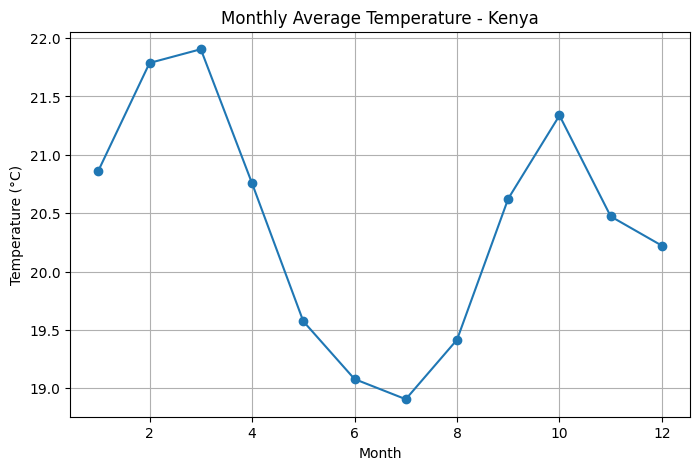

In [26]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(marker='o')
plt.title("Monthly Average Temperature - Kenya")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

## Temperature Trend Analysis

The monthly average temperature in Kenya shows a clear seasonal pattern over the year.

Temperatures gradually increase from January and peak in March, which is the warmest month with an average temperature of approximately 21.9°C. After March, temperatures begin to decline, reaching their lowest point in July, the coolest month, with an average temperature of around 18.9°C.

Following this dip, temperatures rise again from August through October, indicating a second, smaller warm period before slightly decreasing toward the end of the year.

This pattern suggests a bimodal temperature cycle, which is consistent with Kenya’s equatorial climate, where temperature variations are moderate but still influenced by seasonal atmospheric changes.

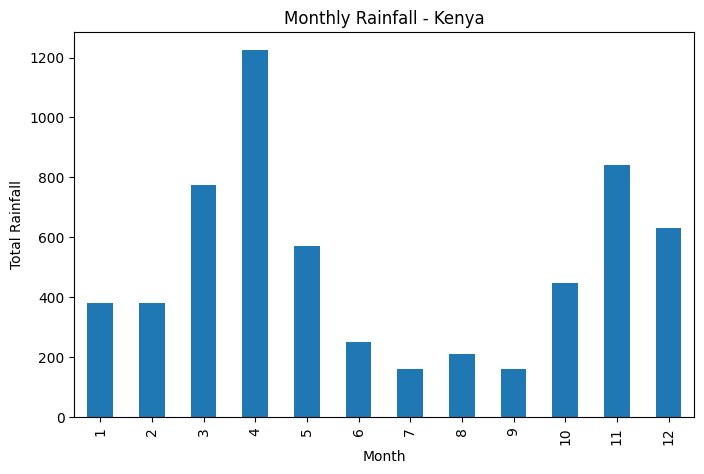

In [28]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall - Kenya")
plt.xlabel("Month")
plt.ylabel("Total Rainfall")
plt.show()

## Rainfall Pattern Analysis

The monthly rainfall distribution in Kenya exhibits a clear bimodal pattern, characterized by two distinct rainy seasons.

The primary peak occurs in April, representing the long rainy season. Rainfall begins to increase in March, reaches its maximum in April, and gradually declines through May. This period contributes the largest share of annual precipitation.

A secondary peak is observed in November, corresponding to the short rainy season. Rainfall increases again from October, peaks in November, and slightly decreases in December.

Between June and September, rainfall remains relatively low, indicating a pronounced dry season.

This bimodal rainfall pattern is typical of Kenya’s equatorial climate and is largely influenced by the seasonal movement of the Intertropical Convergence Zone (ITCZ), which brings rainfall twice a year as it shifts north and south across the region.

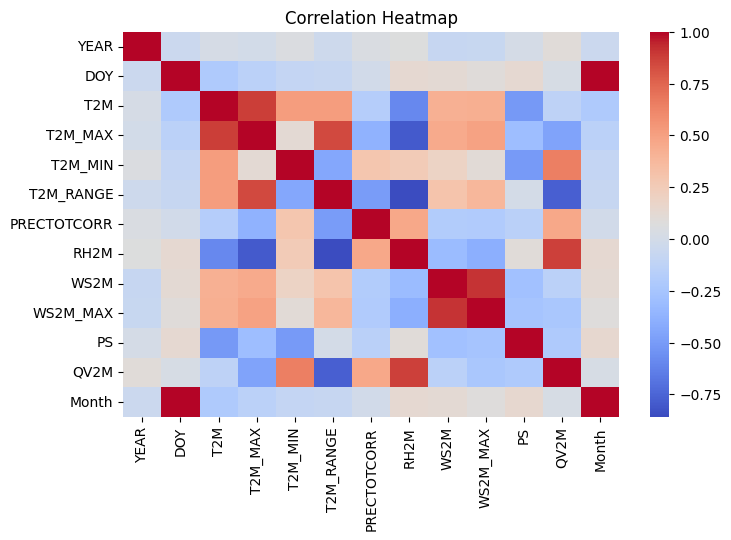

In [29]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

The correlation heatmap highlights the relationships between key climate variables in Kenya.

Strong positive correlations are observed between T2M (average temperature) and both T2M_MAX and T2M_MIN, indicating that daily temperature extremes closely follow the average temperature. Similarly, WS2M (wind speed) and WS2M_MAX show a very strong positive relationship, suggesting that higher average wind speeds are associated with stronger maximum wind speeds.

A strong negative correlation exists between temperature (T2M) and relative humidity (RH2M), indicating that higher temperatures are generally associated with lower humidity levels. This reflects typical atmospheric behavior in warm regions.

Additionally, rainfall (PRECTOTCORR) shows a positive correlation with humidity (RH2M), suggesting that higher humidity levels are linked to increased precipitation.

Overall, the observed correlations align with expected climate patterns and confirm the consistency and reliability of the dataset.


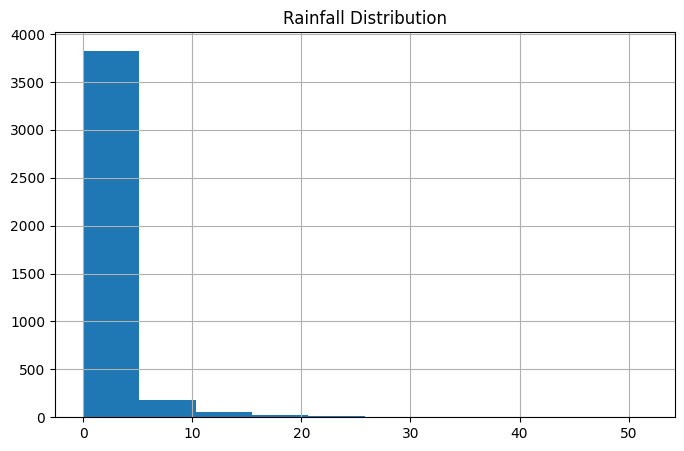

In [30]:
df["PRECTOTCORR"].hist()
plt.title("Rainfall Distribution")
plt.show()

## Rainfall Distribution Analysis

The rainfall distribution is highly right-skewed, with most days having little to no rainfall. A small number of days show very high rainfall, creating a long tail. This indicates that dry days are common, while heavy rainfall events are rare but significant.

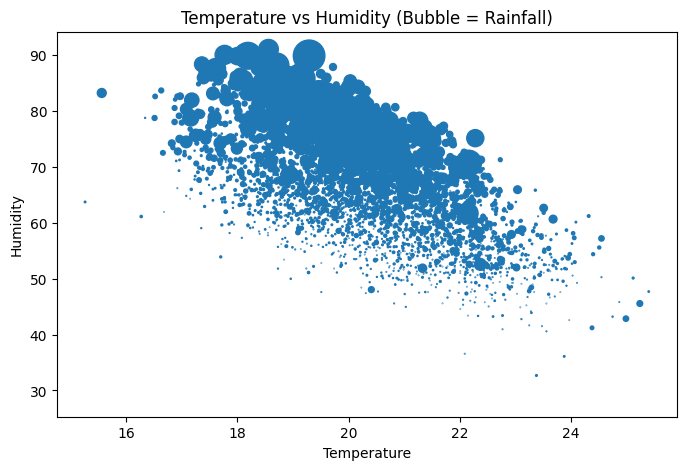

In [31]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

## Temperature vs Humidity Analysis

The scatter plot shows a clear negative relationship between temperature and humidity, where higher temperatures are associated with lower humidity levels.

Larger bubbles, representing higher rainfall, are mostly concentrated in areas with higher humidity and moderate temperatures. This indicates that rainfall is more likely to occur when humidity levels are high.

Overall, the plot highlights the strong link between humidity and rainfall, as well as the inverse relationship between temperature and humidity.